<h1>CIFAR-10 - (CNN layer 사용하기)</h1>
<br>
32 X 32 X 3의 해상도의 컬러 사물 데이터를 모아 놓은 데이터 세트다. CIFAR-10 데이터 세트는 총 10개의 클래스로 구성된다. 학습 데이터는 50,000개이고, 테스트 데이터는 10,000개다.<br>
Lable = <b>[airplane, automobile, bird, cat,deer, dog, frog, horse, ship, truck]</b>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import cifar10


(x_train, y_train),(x_test, y_test) = cifar10.load_data()
print(x_train.shape) # (50000, 32, 32, 3) -> 채널이 3 : 컬러
print(y_train.shape) # (50000, 1)
print(x_test.shape) # (10000, 32, 32, 3)
print(y_test.shape) # (10000, 1)

# print(x_train[0])
print(y_train[0]) # [6]

# 정규화
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-Hot encoding(희소벡터 생성하기)
NUM_CLASSES = 10
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)
print(y_train[0])
# [6] => [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)
[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


Flatten -> (None, 32, 32, 3)을 받으면 ->  (None, 32 x 32 x 3)을 해서 ->  (None, **)Dense로 넘김 <br>
GlobalAveragePooling2D -> (None, 32, 32, 3)을 받으면 -> 바로(None, **)Dense로 넘김 <br>

In [ ]:
# 모델 정의

# Convolution네트워크 구성
def conv_bolck(x, filters):
  x = layers.Conv2D(filters=filters, kernel_size=3, padding='same', use_bias=False)(x)
  x = layers.BatchNormalization()(x) # 학습이 안정적으로 진행됨, 과적합 방지
  x = layers.ReLU()(x)
  return x


inputs = layers.nputs(shape=(32,32,3))

# Stage1 - Convolution을 연속적으로 진행 할 수 있다.
x = conv_bolck(inputs, 32)      # 합성곱
x = conv_bolck(x, 32)           # 합성곱
x = layers.MaxPooling2D()(x)    # pooling(크기를 줄임)

# Stage2
x = conv_bolck(x, 64)
x = conv_bolck(x, 64)
x = layers.MaxPooling2D()(x)

# Stage3
x = conv_bolck(x, 128)
x = conv_bolck(x, 128)
x = layers.MaxPooling2D()(x)

# 분류기 생성
# 최근 Flatten 대신 GlobalAveragePooling2D 사용.
# GlobalAveragePooling2D : 4차원을 2차원으로 줄여주기 때문에 Flatten사용 안함.
# CNN의 마지막 Conv출력이 (batch_size, hight, wighth, channel)형태인데 이를 채널 평균값을 하나씩 뽑는 방식 사용
# 장점 : 파라미터수가 줄어든다. 과적합 방지에 효과적
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(rate = 0.2)(x)
x = layers.Dense(units=128, activation='relu')(x)
x = layers.Dropout(rate = 0.2)(x)
outputs = layers.Dense(units=NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs, name='cifar10_cnn')
print(model.summary())

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             

 Total params: 306,154 (1.17 MB)

 Trainable params: 305,258 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

None


In [6]:
# compile / fit
opti = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(
    loss='categorical_crossentropy',
    optimizer=opti,
    metrics=['accuracy']
)
es = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)
history = model.fit(
    x=x_train, y=y_train, epochs=100, batch_size=128, validation_split=0.1, verbose=2, shuffle=True, callbacks=[es]
)
test_loss , test_acc = model.evaluate(x_test, y_test, verbose=0, batch_size=128)
# 모델 평가하기 (train, test평가 점수의 차이가 크면 overfitting 의심)
print(f'test acc :%.4f'%test_acc)
print(f'test loss :%.4f'%test_loss)

Epoch 1/100
352/352 - 18s - 50ms/step - accuracy: 0.7732 - loss: 0.6493 - val_accuracy: 0.6906 - val_loss: 0.8968
Epoch 2/100
352/352 - 5s - 14ms/step - accuracy: 0.8001 - loss: 0.5712 - val_accuracy: 0.6848 - val_loss: 1.0045
Epoch 3/100
352/352 - 5s - 15ms/step - accuracy: 0.8175 - loss: 0.5259 - val_accuracy: 0.6550 - val_loss: 1.0738
Epoch 4/100
352/352 - 10s - 29ms/step - accuracy: 0.8371 - loss: 0.4706 - val_accuracy: 0.7160 - val_loss: 0.8882
Epoch 5/100
352/352 - 5s - 14ms/step - accuracy: 0.8526 - loss: 0.4250 - val_accuracy: 0.7580 - val_loss: 0.7330
Epoch 6/100
352/352 - 5s - 15ms/step - accuracy: 0.8658 - loss: 0.3890 - val_accuracy: 0.7996 - val_loss: 0.5911
Epoch 7/100
352/352 - 5s - 14ms/step - accuracy: 0.8777 - loss: 0.3516 - val_accuracy: 0.7302 - val_loss: 0.9473
Epoch 8/100
352/352 - 5s - 15ms/step - accuracy: 0.8876 - loss: 0.3255 - val_accuracy: 0.7786 - val_loss: 0.7081
Epoch 9/100
352/352 - 6s - 17ms/step - accuracy: 0.8976 - loss: 0.2945 - val_accuracy: 0.6620 

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
예측값 : ['cat' 'ship' 'ship' 'ship' 'frog' 'frog' 'truck' 'frog' 'cat' 'ship']
실제값 : ['cat' 'ship' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'frog' 'cat'
 'automobile']
분류 실패 수 : 3


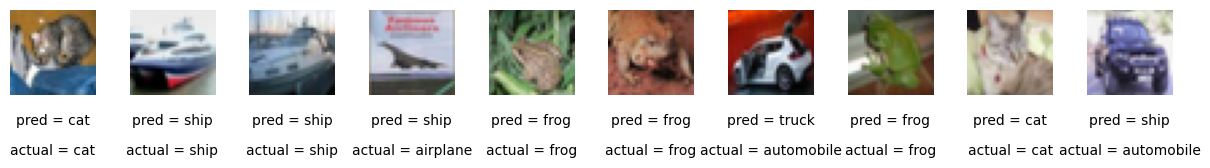

In [7]:
CLASSES = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# 예측하기
pred = model.predict(x_test)
pred = CLASSES[np.argmax(pred[:10], axis=-1)] # axis = 0:열방향, 1:행방향, -1:행단위 뒤에서 부터 처리(마지막 축을 의미)
actual = CLASSES[np.argmax(y_test[:10], axis=-1)]
print('예측값 :',pred)
print('실제값 :',actual)
print('분류 실패 수 :',np.sum(pred != actual))

# 시각화 하기
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4) # subplot사이 간격 조정

for i, idx in enumerate(range(len(x_test[:10]))):
    img = x_test[idx]
    ax = fig.add_subplot(1, len(x_test[:10]), i + 1)
    ax.axis('off')
    ax.imshow(img)

    # transform=ax.transAxes : 이미지 픽셀 좌표 대신에 subplot 영역 기준이다.
    # 0.5 : 가운데 정렬/ 0.0 : 왼쪽 정렬/ 1.0 : 오른쪽 정렬
    ax.text(0.5, -0.35, 'pred = '+str(pred[idx]), fontsize=10, ha='center', transform=ax.transAxes)
    ax.text(0.5, -0.7, 'actual = '+str(actual[idx]), fontsize=10, ha='center', transform=ax.transAxes)
plt.show()